# Inherited Houses Price Prediction

## Objectives
* Load the trained model and predict prices for the 4 inherited houses
* Visualize the inherited houses predictions on the same regression plots

## Inputs
* Trained model: outputs/ml_pipeline/price_prediction_pipeline.pkl
* Inherited houses data: Data Input/inherited_houses.csv
* Training/test data: outputs/datasets/collection/HouseFeaturesPrices.csv

## Outputs
* Predictions for the 4 inherited houses
* Visualization plots showing where inherited houses fall on the regression plots

---

# Change working directory

In [1]:
import os
current_dir = os.getcwd()
current_dir

'c:\\Users\\guilh\\Vscode_projects\\Housing3\\CI_P5_House_Pricing\\jupyter_notebooks'

In [2]:
os.chdir(os.path.dirname(current_dir))
print("You set a new current directory")

You set a new current directory


In [3]:
current_dir = os.getcwd()
current_dir

'c:\\Users\\guilh\\Vscode_projects\\Housing3\\CI_P5_House_Pricing'

---

# Load Data and Model

In [4]:
import pandas as pd
import numpy as np
import pickle
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

sns.set_style('whitegrid')

In [5]:
# Load the full dataset
df = pd.read_csv("outputs/datasets/collection/HouseFeaturesPrices.csv")
print(f"Full dataset shape: {df.shape}")
df.head()

Full dataset shape: (1460, 24)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd,SalePrice
0,856,854.0,3.0,No,706,GLQ,150,0.0,548,RFn,...,65.0,196.0,61,5,7,856,0.0,2003,2003,208500
1,1262,0.0,3.0,Gd,978,ALQ,284,NaN,460,RFn,...,80.0,0.0,0,8,6,1262,NaN,1976,1976,181500
2,920,866.0,3.0,Mn,486,GLQ,434,0.0,608,RFn,...,68.0,162.0,42,5,7,920,NaN,2001,2002,223500
3,961,NaN,NaN,No,216,ALQ,540,NaN,642,Unf,...,60.0,0.0,35,5,7,756,NaN,1915,1970,140000
4,1145,NaN,4.0,Av,655,GLQ,490,0.0,836,RFn,...,84.0,350.0,84,5,8,1145,NaN,2000,2000,250000


In [6]:
# Load inherited houses
inherited_houses = pd.read_csv("Data Input/inherited_houses.csv")
print(f"Inherited houses shape: {inherited_houses.shape}")
inherited_houses

Inherited houses shape: (4, 23)


,1stFlrSF,2ndFlrSF,BedroomAbvGr,BsmtExposure,BsmtFinSF1,BsmtFinType1,BsmtUnfSF,EnclosedPorch,GarageArea,GarageFinish,...,LotArea,LotFrontage,MasVnrArea,OpenPorchSF,OverallCond,OverallQual,TotalBsmtSF,WoodDeckSF,YearBuilt,YearRemodAdd
0,896,0,2,No,468.0,Rec,270.0,0,730.0,Unf,...,11622,80.0,0.0,0,6,5,882.0,140,1961,1961
1,1329,0,3,No,923.0,ALQ,406.0,0,312.0,Unf,...,14267,81.0,108.0,36,6,6,1329.0,393,1958,1958
2,928,701,3,No,791.0,GLQ,137.0,0,482.0,Fin,...,13830,74.0,0.0,34,5,5,928.0,212,1997,1998
3,926,678,3,No,602.0,GLQ,324.0,0,470.0,Fin,...,9978,78.0,20.0,36,6,6,926.0,360,1998,1998


In [7]:
# Load the trained model
model_path = "outputs/ml_pipeline/price_prediction_pipeline.pkl"

with open(model_path, 'rb') as file:
    pipeline = pickle.load(file)
    
print(f"Model loaded from {model_path}")

Model loaded from outputs/ml_pipeline/price_prediction_pipeline.pkl


---

# Prepare Training and Test Sets (Same as in notebook 04)

In [8]:
# Fill missing values (same as in notebook 04)
df_filled = df.copy()
object_cols = df.columns[df.dtypes=='object'].to_list()

# Fill missing values in object columns
for col in object_cols:
    df_filled[col] = df_filled[col].fillna('Unknown')  

# For numeric columns, filling with median
numeric_cols = df.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    df_filled[col] = df_filled[col].fillna(df_filled[col].median())

print("Missing values after filling:")
print(df_filled.isnull().sum().sum())

Missing values after filling:
0


In [9]:
# Split data (same as in notebook 04)
X_train, X_test, y_train, y_test = train_test_split(
    df_filled.drop(['SalePrice'], axis=1),
    df_filled['SalePrice'],
    test_size=0.2,
    random_state=0
)

print("Train set:", X_train.shape, y_train.shape)
print("Test set:", X_test.shape, y_test.shape)

Train set: (1168, 23) (1168,)
Test set: (292, 23) (292,)


---

# Prepare Inherited Houses Data

In [10]:
# Fill missing values in inherited houses (same method as training)
inherited_filled = inherited_houses.copy()

# Fill missing categorical values
for col in inherited_filled.select_dtypes(include=['object']).columns:
    inherited_filled[col] = inherited_filled[col].fillna('Unknown')

# Fill missing numerical values with training data median
for col in inherited_filled.select_dtypes(include=[np.number]).columns:
    if inherited_filled[col].isnull().any():
        inherited_filled[col] = inherited_filled[col].fillna(df_filled[col].median())

print("Inherited houses missing values:", inherited_filled.isnull().sum().sum())

Inherited houses missing values: 0


---

# Make Predictions

In [11]:
# Get predictions for train, test, and inherited houses
pred_train = pipeline.predict(X_train)
pred_test = pipeline.predict(X_test)
pred_inherited = pipeline.predict(inherited_filled)

print("Train predictions:", pred_train.shape)
print("Test predictions:", pred_test.shape)
print("Inherited predictions:", pred_inherited.shape)

Train predictions: (1168,)
Test predictions: (292,)
Inherited predictions: (4,)


In [12]:
# Display inherited houses predictions
print("\n" + "="*60)
print("INHERITED HOUSES PRICE PREDICTIONS")
print("="*60)

for i, price in enumerate(pred_inherited, 1):
    print(f"House {i}: ${price:,.0f}")

print("\n" + "-"*60)
print(f"Total Value: ${pred_inherited.sum():,.0f}")
print(f"Average Price: ${pred_inherited.mean():,.0f}")
print(f"Price Range: ${pred_inherited.min():,.0f} - ${pred_inherited.max():,.0f}")
print("="*60)


INHERITED HOUSES PRICE PREDICTIONS
House 1: $125,666
House 2: $158,665
House 3: $183,126
House 4: $188,830

------------------------------------------------------------
Total Value: $656,286
Average Price: $164,072
Price Range: $125,666 - $188,830


---

# Visualize Predictions with Inherited Houses

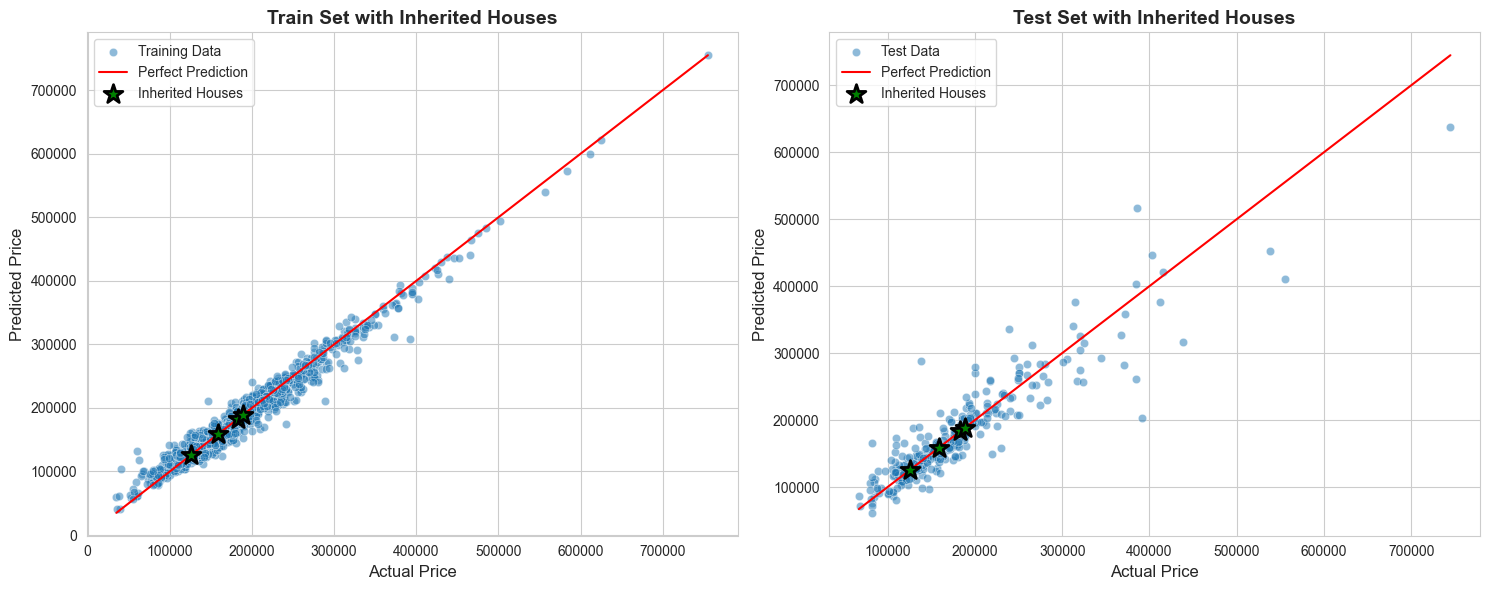

In [13]:
# Create regression plots with inherited houses highlighted
fig, axes = plt.subplots(nrows=1, ncols=2, figsize=(15, 6))

# Train set plot
sns.scatterplot(x=y_train, y=pred_train, alpha=0.5, ax=axes[0], label='Training Data')
sns.lineplot(x=y_train, y=y_train, color='red', ax=axes[0], label='Perfect Prediction')

# Since inherited houses don't have actual prices, we plot them at their predicted values
# on the x-axis to show where they fall in the price distribution
axes[0].scatter(pred_inherited, pred_inherited, color='green', s=200, marker='*', 
                edgecolors='black', linewidths=2, label='Inherited Houses', zorder=5)

axes[0].set_xlabel("Actual Price", fontsize=12)
axes[0].set_ylabel("Predicted Price", fontsize=12)
axes[0].set_title("Train Set with Inherited Houses", fontsize=14, fontweight='bold')
axes[0].legend()

# Test set plot
sns.scatterplot(x=y_test, y=pred_test, alpha=0.5, ax=axes[1], label='Test Data')
sns.lineplot(x=y_test, y=y_test, color='red', ax=axes[1], label='Perfect Prediction')

axes[1].scatter(pred_inherited, pred_inherited, color='green', s=200, marker='*', 
                edgecolors='black', linewidths=2, label='Inherited Houses', zorder=5)

axes[1].set_xlabel("Actual Price", fontsize=12)
axes[1].set_ylabel("Predicted Price", fontsize=12)
axes[1].set_title("Test Set with Inherited Houses", fontsize=14, fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.show()

---

# Price Distribution Comparison

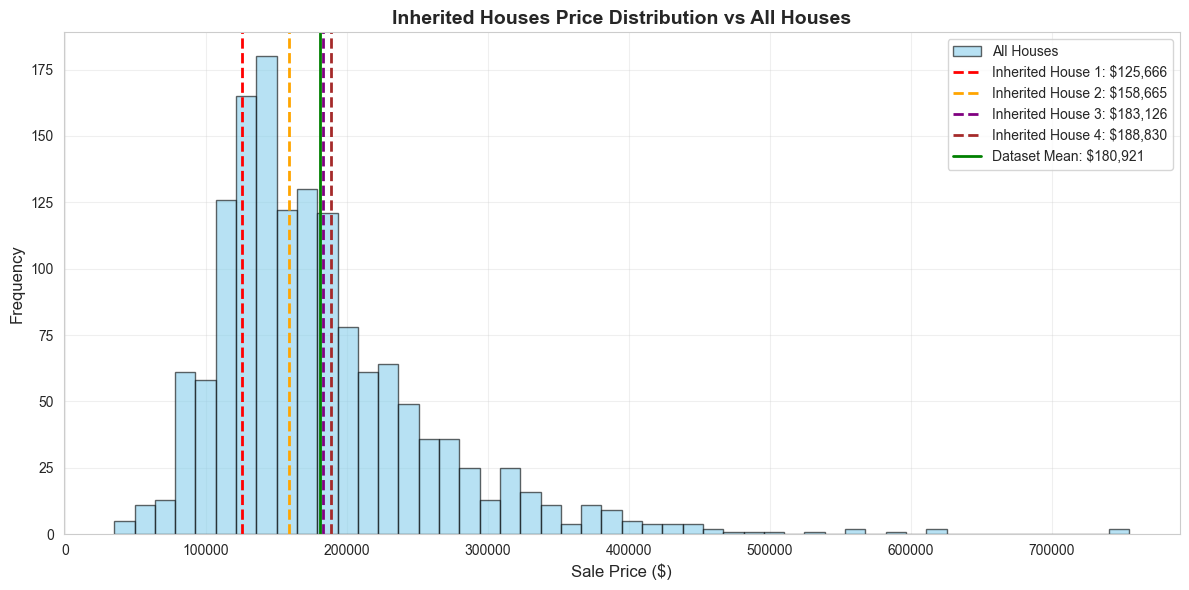

In [14]:
# Compare inherited houses to the overall price distribution
fig, ax = plt.subplots(figsize=(12, 6))

# Plot distribution of all prices
ax.hist(df_filled['SalePrice'], bins=50, alpha=0.6, label='All Houses', color='skyblue', edgecolor='black')

# Plot inherited house predictions as vertical lines
colors = ['red', 'orange', 'purple', 'brown']
for i, (price, color) in enumerate(zip(pred_inherited, colors), 1):
    ax.axvline(price, color=color, linestyle='--', linewidth=2, label=f'Inherited House {i}: ${price:,.0f}')

# Add mean line
mean_price = df_filled['SalePrice'].mean()
ax.axvline(mean_price, color='green', linestyle='-', linewidth=2, label=f'Dataset Mean: ${mean_price:,.0f}')

ax.set_xlabel('Sale Price ($)', fontsize=12)
ax.set_ylabel('Frequency', fontsize=12)
ax.set_title('Inherited Houses Price Distribution vs All Houses', fontsize=14, fontweight='bold')
ax.legend(loc='upper right')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---

# Summary Statistics

In [15]:
# Create summary dataframe
summary = pd.DataFrame({
    'House': [f'House {i}' for i in range(1, 5)],
    'Predicted Price': [f'${p:,.0f}' for p in pred_inherited],
    'vs Dataset Mean': [f'{((p - mean_price) / mean_price * 100):+.1f}%' for p in pred_inherited],
    'Percentile': [f'{(df_filled["SalePrice"] < p).mean() * 100:.1f}%' for p in pred_inherited]
})

print("\nInherited Houses Summary:")
print(summary.to_string(index=False))

print(f"\nDataset Statistics:")
print(f"  Mean Price: ${mean_price:,.0f}")
print(f"  Median Price: ${df_filled['SalePrice'].median():,.0f}")
print(f"  Min Price: ${df_filled['SalePrice'].min():,.0f}")
print(f"  Max Price: ${df_filled['SalePrice'].max():,.0f}")


Inherited Houses Summary:
  House Predicted Price vs Dataset Mean Percentile
House 1        $125,666          -30.5%      21.6%
House 2        $158,665          -12.3%      47.4%
House 3        $183,126           +1.2%      62.5%
House 4        $188,830           +4.4%      65.5%

Dataset Statistics:
  Mean Price: $180,921
  Median Price: $163,000
  Min Price: $34,900
  Max Price: $755,000
